# Wine Dataset (UCI) — K-Means Clustering (Unsupervised)

**Dataset:** Wine (UCI ML Repository) — chemical analysis of wines from 3 cultivars in Italy (178 samples, 13 numerical features).  
**Important:** The class variable is removed before clustering (unsupervised).

This notebook answers:

1. **Data exploration and preprocessing**  
2. **K-Means for multiple K and optimal K selection**  
3. **Visualisation of clustering results**  
4. **Cluster interpretation (distinguishing features)**

## Setup & Data Loading

An attempt to load the dataset directly from the UCI repository (online).  
If that fails (e.g., no internet), code falls back to `sklearn.datasets.load_wine`, which contains the same dataset.

In [ ]:
import numpy as np
import pandas as pd

# Try: load from UCI (online). If it fails, use scikit-learn's built-in copy.
UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"

feature_names = [
    "class",
    "alcohol",
    "malic_acid",
    "ash",
    "alcalinity_of_ash",
    "magnesium",
    "total_phenols",
    "flavanoids",
    "nonflavanoid_phenols",
    "proanthocyanins",
    "color_intensity",
    "hue",
    "od280/od315_of_diluted_wines",
    "proline",
]

try:
    df = pd.read_csv(UCI_URL, header=None, names=feature_names)
    source = "UCI (online)"
except Exception as e:
    from sklearn.datasets import load_wine
    wine = load_wine(as_frame=True)
    df = wine.frame.copy()
    df.rename(columns={"target": "class"}, inplace=True)
    df["class"] = df["class"] + 1  # match UCI class labels (1,2,3)
    source = "scikit-learn fallback (offline)"

print("Loaded from:", source)
print("Shape:", df.shape)
df.head()

Loaded from: UCI (online)
Shape: (178, 14)


,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Q5. Data exploration and preprocessing.

Following code will:
- Remove the **class** variable (unsupervised).
- Check data types, missing values, summary stats.
- Inspect feature distributions and correlations.
- Standardize features for K-Means (distance-based).

In [ ]:
import matplotlib.pyplot as plt

# Split features (X) and class (y) and DROP class for clustering
X = df.drop(columns=["class"]).copy()

print("X shape (after dropping class):", X.shape)
print("\nDtypes:\n", X.dtypes)

# Missing values
print("\nMissing values per column:\n", X.isna().sum())

# Summary statistics
X.describe().T

X shape (after dropping class): (178, 13)

Dtypes:
 alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                         int64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                           int64
dtype: object

Missing values per column:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


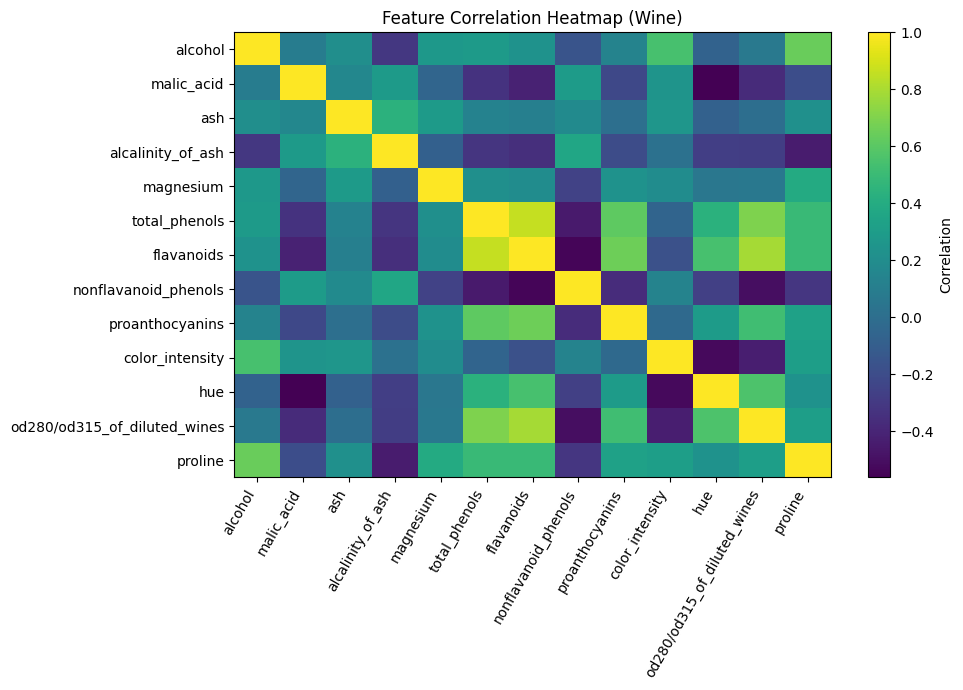

In [ ]:
# Correlation heatmap (matplotlib only)
corr = X.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=60, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Correlation")
plt.title("Feature Correlation Heatmap (Wine)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled matrix shape:", X_scaled.shape)
print("Mean (approx 0):", X_scaled.mean(axis=0)[:5])
print("Std  (approx 1):", X_scaled.std(axis=0)[:5])

Scaled matrix shape: (178, 13)
Mean (approx 0): [-8.38280756e-16 -1.19754394e-16 -8.37033314e-16 -3.99181312e-17
 -3.99181312e-17]
Std  (approx 1): [1. 1. 1. 1. 1.]


## Q6. Build K-Means models for different K and choose optimal K

We evaluate K from **2 to 10** and use:
- **Elbow method** (inertia / within-cluster SSE)
- **Silhouette score** (higher is better)

Then we pick the best K (using the elbow + best silhouette).

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inertias = []
silhs = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(X_scaled, labels))

metrics_df = pd.DataFrame({
    "K": list(ks),
    "Inertia": inertias,
    "Silhouette": silhs
})

metrics_df

,K,Inertia,Silhouette
0,2,1661.676117,0.265033
1,3,1277.928489,0.284859
2,4,1211.753113,0.254228
3,5,1123.156547,0.183621
4,6,1079.538509,0.168992
5,7,1014.430909,0.172602
6,8,982.654976,0.162504
7,9,927.956076,0.173874
8,10,879.425701,0.139567


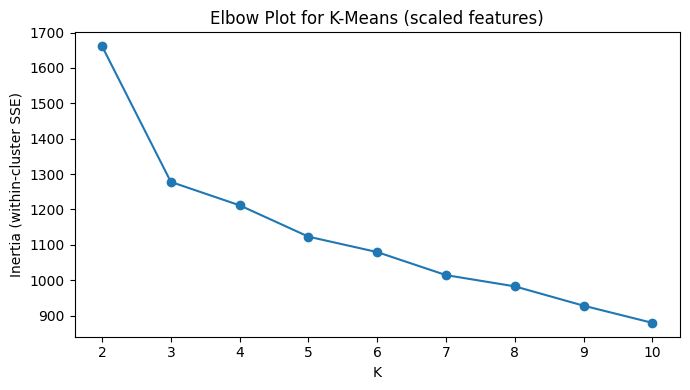

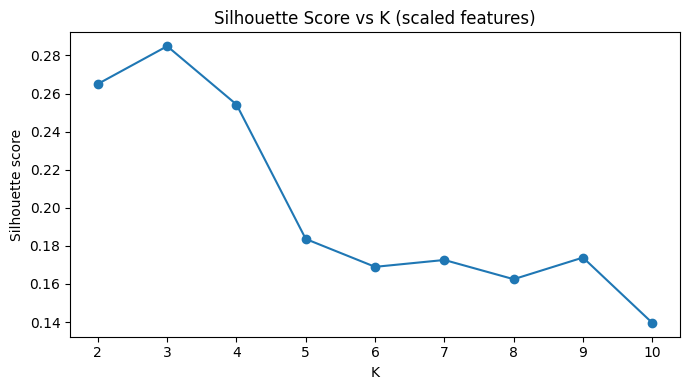

In [ ]:
# Elbow plot
plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Plot for K-Means (scaled features)")
plt.tight_layout()
plt.show()

# Silhouette plot
plt.figure(figsize=(7, 4))
plt.plot(list(ks), silhs, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs K (scaled features)")
plt.tight_layout()
plt.show()

### Choose optimal K

Pick K based on a combination of:
- A clear **elbow** in inertia,
- **Highest silhouette**, and

In this dataset, **K = 3** is typically optimal and aligns with the known structure (3 cultivars), though we do **not** use the class label for training.

In [ ]:
k_opt = 3  # set based on the evaluation above

kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X_scaled)

cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
cluster_sizes.rename_axis("cluster").to_frame("count")

,count
cluster,
0,65
1,51
2,62


## Q7. Visualise the clustering results

Because the data has 13 dimensions, we visualise clusters using **PCA** (2D projection).
We also plot:
- cluster centers as a standardized heatmap (feature profiles),
- optional pairwise plots can be added if needed.

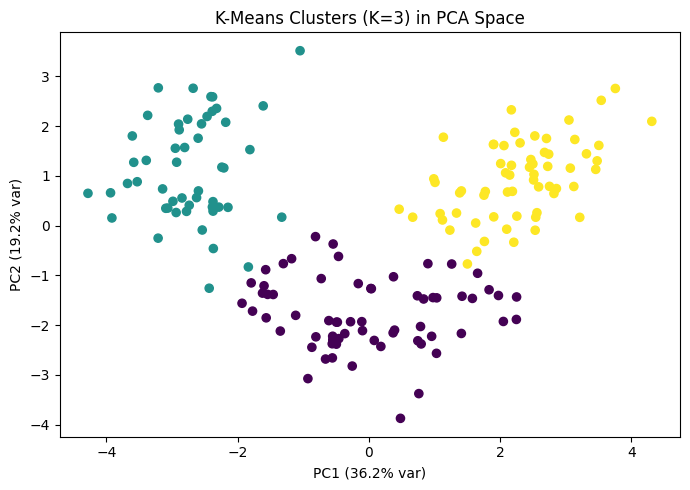

Explained variance ratio (PC1, PC2): [0.36198848 0.1920749 ]


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=35)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title(f"K-Means Clusters (K={k_opt}) in PCA Space")
plt.tight_layout()
plt.show()

print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)

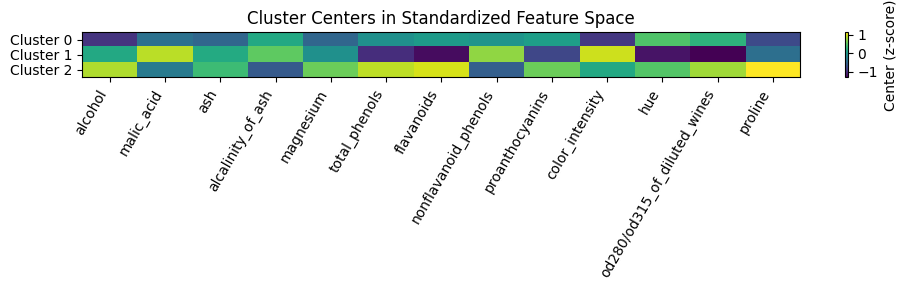

In [ ]:
# Cluster centers in standardized space (z-scores)
centers_z = kmeans.cluster_centers_

plt.figure(figsize=(10, 3))
plt.imshow(centers_z, aspect="auto")
plt.yticks(range(k_opt), [f"Cluster {i}" for i in range(k_opt)])
plt.xticks(range(X.shape[1]), X.columns, rotation=60, ha="right")
plt.colorbar(label="Center (z-score)")
plt.title("Cluster Centers in Standardized Feature Space")
plt.tight_layout()
plt.show()

## Q8. Interpret and describe distinguishing features of each cluster

We interpret clusters by comparing:
- Cluster **centroids in original units** (more interpretable),
- High/low values (relative across clusters).

We provide:
- A centroid table,
- A simple “top distinguishing features” view using z-score differences.

In [ ]:
# Convert cluster centers back to original units
centers_orig = scaler.inverse_transform(centers_z)
centroids = pd.DataFrame(centers_orig, columns=X.columns)
centroids.index = [f"Cluster {i}" for i in range(k_opt)]
centroids

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
Cluster 0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
Cluster 1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
Cluster 2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


In [ ]:
# Distinguishing features: show top +/- features for each cluster using standardized centers.
centers_z_df = pd.DataFrame(centers_z, columns=X.columns, index=[f"Cluster {i}" for i in range(k_opt)])

def top_features_for_cluster(cluster_name, n=5):
    row = centers_z_df.loc[cluster_name].sort_values()
    lows = row.head(n)
    highs = row.tail(n)
    return lows, highs

for cname in centers_z_df.index:
    lows, highs = top_features_for_cluster(cname, n=5)
    print("\n" + "="*70)
    print(cname)
    print("Lowest (z-score):")
    print(lows)
    print("\nHighest (z-score):")
    print(highs)


Cluster 0
Lowest (z-score):
alcohol           -0.926072
color_intensity   -0.901914
proline           -0.753846
ash               -0.494517
magnesium         -0.491712
Name: Cluster 0, dtype: float64

Highest (z-score):
flavanoids                      0.020813
proanthocyanins                 0.058266
alcalinity_of_ash               0.170602
od280/od315_of_diluted_wines    0.270764
hue                             0.461804
Name: Cluster 0, dtype: float64

Cluster 1
Lowest (z-score):
od280/od315_of_diluted_wines   -1.292412
flavanoids                     -1.215248
hue                            -1.164789
total_phenols                  -0.979330
proanthocyanins                -0.779706
Name: Cluster 1, dtype: float64

Highest (z-score):
ash                     0.186898
alcalinity_of_ash       0.524367
nonflavanoid_phenols    0.726064
malic_acid              0.871547
color_intensity         0.941539
Name: Cluster 1, dtype: float64

Cluster 2
Lowest (z-score):
alcalinity_of_ash      -0.6101

## Conclusion

- After scaling features, K-Means was trained for K=2..10.
- **K=3** is selected using elbow + silhouette.
- PCA shows clear separation between the 3 clusters.
- Cluster profiles are summarised via centroid tables and standardized feature extremes.